# Agentic RAG Chatbot - "Attention Is All You Need"

This notebook demonstrates an Agentic RAG (Retrieval-Augmented Generation) pipeline built with LangGraph. The system can autonomously decide wether to reactive information evaluate retrieved documents for relevance, rewrite queries when results are poor, and check its own answers for hallucinations.

**Data source:** [Attention Is All You Need](https://arxiv.org/pdf/1706.03762) (Vaswani et al., 2017)

**Key patterns implemented:**
- Adaptive routing (retrieval vs. direct answer)
- Corrective RAG (document grading + query rewriting)
- Self-RAG (hallucination check + answer grading)

## Architecture overview

### Design decisions

- **LangGraph over plain LangChain** — LangGraph enables conditional branching and
  retry loops, which are essential for agentic behavior. A linear chain cannot route
  back to earlier steps based on evaluation results.
- **Section-based chunking over fixed-size** — The paper has clear section boundaries.
  Preserving these ensures chunks are semantically coherent and metadata (section id,
  title) can be attached for source attribution.
- **Task-specific models** — Using flan-t5 for all nodes due to compute constraints.
  Classification tasks (routing, grading) use simpler prompts; generation uses more
  detailed prompts. The pipeline is model-agnostic by design.
- **ChromaDB over FAISS** — ChromaDB supports metadata filtering and persistent storage
  out of the box, which simplifies the retrieval pipeline.
- **Cosine similarity** — Standard choice for sentence-transformer embeddings, where
  vectors are normalized.

### Pipeline logic

1. **Router** — classifies question as paper-related or general (LLM + keyword fallback)
2. **Retriever** — top-5 chunks from ChromaDB via cosine similarity
3. **Document grader** — LLM evaluates each chunk's relevance (yes/no)
4. **Query rewriter** — reformulates question for better retrieval (max 2 retries)
5. **Generator** — produces answer grounded in retrieved context
6. **Hallucination check** — verifies answer is supported by context
7. **Answer grader** — verifies answer addresses the question
8. **Fallback** — returns "no information found" after retry limit

### Agentic patterns implemented

- **Adaptive RAG** — router decides retrieval vs. direct answer
- **Corrective RAG** — grader rejects poor chunks, rewriter reformulates query
- **Self-RAG** — hallucination check and answer grading with retry loops

## 1. Setup and dependencies

Installing the required packages. Key components:
- **LangGraph** - state machine framework for the agentic pipeline
- **ChromaDB** - vector store for document embeddings
- **sentence-transformers** - multilingual embedding model
- **transformers + bitsandbytes** - local LLM inference with 4-bit quantization
- **PyMuPDF** - PDF text extraction

In [ ]:
!pip install -q langgraph langchain langchain-core langchain-text-splitters langchain-community sentence-transformers chromadb pymupdf transformers bitsandbytes accelerate

!pip freeze | grep -E "langgraph|langchain|sentence-transformers|chromadb|pymupdf|transformers|torch|bitsandbytes|accelerate"

accelerate==1.13.0
bitsandbytes==0.49.2
chromadb==1.5.7
langchain==1.2.14
langchain-classic==1.0.3
langchain-community==0.4.1
langchain-core==1.2.23
langchain-text-splitters==1.1.1
langgraph==1.1.4
langgraph-checkpoint==4.0.1
langgraph-prebuilt==1.0.8
langgraph-sdk==0.3.12
sentence-transformers==5.3.0
torch @ https://download.pytorch.org/whl/cpu/torch-2.10.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl
torchao==0.10.0
torchaudio @ https://download.pytorch.org/whl/cpu/torchaudio-2.10.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl
torchcodec @ https://download.pytorch.org/whl/cpu/torchcodec-0.10.0-cp312-cp312-manylinux_2_28_x86_64.whl
torchdata==0.11.0
torchsummary==1.5.1
torchtune==0.6.1
torchvision @ https://download.pytorch.org/whl/cpu/torchvision-0.25.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl
transformers==5.0.0


## 2. Document loading

Downloading the original Transformer paper from arXiv and extracting raw text using PyMuPDF. This serves as our knowledge base - a single, well known paper is sufficient to demonstrate the full pipeline. The architecture is designed to scale to hundreds of documents without modifications.

In [ ]:
!wget -q -O attention.pdf https://arxiv.org/pdf/1706.03762

import fitz
doc = fitz.open("attention.pdf")

print(f"Total pages: {len(doc)}")
print(f"First 500 character of the first page:\n{doc[0].get_text()[:500]}")

Total pages: 15
First 500 character of the first page:
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗†
University of Toronto
aidan@cs.toronto.edu
Łukasz K


##3. Document chunking

Splitting the paper into semantically meaningful chunks. The strategy is combines section-based splitting (preserving local boundaries like "3.2.1 Scaled Dot-Product Attention") with recursive character splitting for sections that exceed the token limit. Each chunk carries metadata (section id, title) for source attribution in generated answers.

In [ ]:
import fitz
import re

# Extract full text from PDF
doc = fitz.open("attention.pdf")
full_text = ""
for page in doc:
  text = page.get_text()
  text = re.sub(r'\n\s*\d+\s*$', '\n', text)
  full_text += text

# Cleaning
full_text = re.sub(r'arXiv:\d+\.\d+v\d+\s*\[.*?\]\s*\d+\s+\w+\s+\d{4}', '', full_text)
full_text = re.sub(r'\n{3,}', '\n\n', full_text)

# Split into sections based on heading pattern
section_pattern = re.compile(r'\n\s*(\d{1,2}(?:\.\d{1,2})*)\s+([A-Z][^\n]+)(?=\n)')
matches = list(section_pattern.finditer(full_text))

matches = [m for m in matches if not re.match(
    r'(Figure|Table)', m.group(2)
) and int(m.group(1).split('.')[0]) <= 7]

sections = []
for i, match in enumerate(matches):
  section_id = match.group(1)
  section_title = match.group(2).strip()
  start = match.end()
  end = matches[i +1 ].start() if i < len(matches) - 1 else len(full_text)
  content = full_text[start:end].strip()

  sections.append({
      "section_id": section_id,
      "section_title": section_title,
      "content": content,
  })

# Add abstract manually
abstract_end = matches[0].start() if matches else len(full_text)
abstract_text = full_text[:abstract_end]
abstract_match = re.search(r'Abstract\n(.*?)(?=\n\d)', abstract_text, re.DOTALL)
if abstract_match:
  sections.insert(0,{
      "section_id": "Abs",
      "section_title": "Abstract",
      "content": abstract_match.group(1).strip(),
  })

# Add References manually
if sections:
  last_section = sections[-1]
  tail_text = last_section["content"]

  ref_match = re.search(r'\n\s*References\s*\n', tail_text)
  vis_match = re.search(r'\n\s*Attention Visualizations\s*\n', tail_text)

  if ref_match:
    last_section["content"] = tail_text[:ref_match.start()].strip()

    ref_start = ref_match.end()
    ref_end = vis_match.start() if vis_match else len(tail_text)

    sections.append({
        "section_id": "Ref",
        "section_title": "References",
        "content": tail_text[ref_start:ref_end].strip(),
    })

  if vis_match:
    vis_start = vis_match.end()
    sections.append({
        "section_id": "Vis",
        "section_title": "Attention Visualizations",
        "content": tail_text[vis_start:].strip(),
    })

print(f"Found {len(sections)} sections:\n")
for s in sections:
  print(f"[{s['section_id']}] {s['section_title']} ({len(s['content'])} chars)")


Found 25 sections:

[Abs] Abstract (2127 chars)
[1] Introduction (1905 chars)
[2] Background (1815 chars)
[3] Model Architecture (744 chars)
[3.1] Encoder and Decoder Stacks (1316 chars)
[3.2] Attention (520 chars)
[3.2.1] Scaled Dot-Product Attention (1497 chars)
[3.2.2] Multi-Head Attention (1419 chars)
[3.2.3] Applications of Attention in our Model (1169 chars)
[3.3] Position-wise Feed-Forward Networks (615 chars)
[3.4] Embeddings and Softmax (1020 chars)
[3.5] Positional Encoding (1386 chars)
[4] Why Self-Attention (3179 chars)
[5] Training (58 chars)
[5.1] Training Data and Batching (591 chars)
[5.2] Hardware and Schedule (398 chars)
[5.3] Optimizer (447 chars)
[5.4] Regularization (1242 chars)
[6] Results (0 chars)
[6.1] Machine Translation (1669 chars)
[6.2] Model Variations (2117 chars)
[6.3] English Constituency Parsing (2397 chars)
[7] Conclusion (1216 chars)
[Ref] References (6994 chars)
[Vis] Attention Visualizations (2318 chars)


## 4. Chunk splitting

Sections that exceed 1000 characters are further split using LangChain's RecursiveCharacterTextSplitter with 200-character overlap to preserve context across chunk boundaries. Short sections remain intact. Each chunk inherits the original section metadata (section id, title, source)

In [ ]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap  = 200,
    length_function = len,
    separators = [r"\n\n", r"\n", r"(?<=\. )", " ", ""]
)

documents = []

for sec in sections:
  if not sec["content"].strip():
    continue

  chunks = text_splitter.create_documents(
      texts = [sec["content"]],
      metadatas = [{
          "source": "Attention Is All You Need",
          "section_id": sec["section_id"],
          "section_title": sec["section_title"],
      }]
  )

  documents.extend(chunks)

print(f"Number of original sections: {len(sections)}")
print(f"Number of chunks: {len(documents)}\n")

test_idx = 15 if len(documents) > 15 else 0
print("Random chunk")
print(f"Contents:\n{documents[test_idx].page_content}")
print(f"Metadata:\n{documents[test_idx].metadata}")


Number of original sections: 25
Number of chunks: 56

Random chunk
Contents:
Instead of performing a single attention function with dmodel-dimensional keys, values and queries,
we found it beneficial to linearly project the queries, keys and values h times with different, learned
linear projections to dk, dk and dv dimensions, respectively. On each of these projected versions of
queries, keys and values we then perform the attention function in parallel, yielding dv-dimensional
4To illustrate why the dot products get large, assume that the components of q and k are independent random
variables with mean 0 and variance 1. Then their dot product, q · k = Pdk
i=1 qiki, has mean 0 and variance dk.
output values. These are concatenated and once again projected, resulting in the final values, as
depicted in Figure 2.
Multi-head attention allows the model to jointly attend to information from different representation
subspaces at different positions. With a single attention head, averaging in

## 5. Embedding and vector store

Embedding chunks using 'all-MiniLM-L6-v2' (384-dim, English-optimized) and storing them in ChromaDB with persistent storage. Metadata fields are indexed for filtered retrieval (e.g. searching only within a specific section)

In [ ]:
from sentence_transformers import SentenceTransformer
import chromadb

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

client = chromadb.Client()

try:
  client.delete_collection(name="attention_paper")
except:
  pass

collection = client.create_collection(
    name = "attention_paper",
    metadata = {"hnsw:space": "cosine"}
    )

texts = [doc.page_content for doc in documents]
metadatas = [doc.metadata for doc in documents]
ids = [f"chunk_{i}" for i in range(len(documents))]

embeddings = embedding_model.encode(texts, show_progress_bar = True)

collection.add(
    ids = ids,
    embeddings = embeddings.tolist(),
    documents = texts,
    metadatas = metadatas
)

# Test query
print(f"Stored {collection.count()} chunks in ChromaDB")

results = collection.query(
    query_embeddings = embedding_model.encode(["What is scaled dot-product attention?"]).tolist(), n_results = 3
)

print("Test query: 'What is scaled dot-product attention?\n")
for i, (doc, metadata) in enumerate(zip(results["documents"][0], results["metadatas"][0])):
  print(f"Result {i + 1} [{metadata['section_id']}] {metadata['section_title']}:")
  print(f"{doc}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Stored 56 chunks in ChormaDB
Test query: 'What is saled dot-product attention?

Result 1 [3.2.1] Scaled Dot-Product Attention:
We call our particular attention "Scaled Dot-Product Attention" (Figure 2). The input consists of
queries and keys of dimension dk, and values of dimension dv. We compute the dot products of the
query with all keys, divide each by √dk, and apply a softmax function to obtain the weights on the
values.
In practice, we compute the attention function on a set of queries simultaneously, packed together
into a matrix Q. The keys and values are also packed together into matrices K and V . We compute
the matrix of outputs as:
Attention(Q, K, V ) = softmax(QKT
√dk
)V
(1)
The two most commonly used attention functions are additive attention [2], and dot-product (multi-
plicative) attention. Dot-product attention is identical to our algorithm, except for the scaling factor
of
1
√dk . Additive attention computes the compatibility function using a feed-forward network with


## 6. LangGraph pipeline

Building the agentic RAG pipeline using LangGraph. The graph implements three key patterns:
- **Adaptive routing** - the LLM decides whether to retrieve or answer directly
- **Corrective RAG** - retrieved documents are graded for relevance, queries are rewritten if needed
- **Self-RAG** - generated answers are checked for hallucinations and usefulness

##

In [ ]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, END

class GraphState(TypedDict):
  question: str
  documents: List[str]
  generation: str
  retry_count: int
  route: str
  rewritten_question: Optional[str]
  hallucination_check: Optional[str]
  answer_grade: Optional[str]

## 6.1 Model loading

Loading a single model for all pipeline nodes:
- **flan-t5-large** (780M) — used for all tasks: routing, grading, rewriting, and generation.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# Rewriter & generator model
gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")
gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-large")


# Function for model calling
def ask_model(model, tokenizer, prompt, max_new_tokens = 256):
  inputs = tokenizer(prompt, return_tensors="pt", truncation = True, max_length = 2048)
  outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
  return tokenizer.decode(outputs[0], skip_special_tokens=True)


# Test
print(ask_model(gen_model, gen_tokenizer, "Is the sky blue? Answer yes or no.", max_new_tokens=10))

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded flan-t5-base


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded flan-t5-large
yes


## 6.2 Node functions

Each node is a Python function that reads from and writes to the shared state.
The pipeline nodes: router ➡ etriever ➡ document grader ➡ query rewriter ➡ generator ➡ hallucination check ➡ answer grader

In [ ]:
def router(state):
  prompt = f"""Is the question about transfromers, attention, neural networks, or machine learning?
  Answer yes or no

  Question: {state['question']}"""

  result = ask_model(gen_model, gen_tokenizer, prompt, max_new_tokens = 10).strip().lower()

  # Keyword fallback
  keywords = ["attention", "transformers", "encoder", "decoder", "embedding", "self-attention", "multi-head",
              "softmax", "bleu", "tranlation", "model", "layer", "training", "positional", "feed-forward"]
  has_keyword = any(kw in state["question"].lower() for kw in keywords)
  route = "retrieve" if ("yes" in result or has_keyword) else "direct"
  print(f" [Router] LLM said '{result}', keyword match: {has_keyword} -> {route}")
  return {"route": route}

def retrieve(state):
  question = state.get("rewritten_question", state["question"])
  query_embedding = embedding_model.encode([question]).tolist()
  results = collection.query(
      query_embeddings = query_embedding,
      n_results = 5
  )
  docs = results["documents"][0]
  metas = results["metadatas"][0]
  print(f" [Retriever] Found {len(docs)} chunks")
  for i,m in enumerate(metas):
    print(f"\t{i+1}. [{m['section_id']}] {m['section_title']}")
  return {"documents": docs}

def grade_documents(state):
  question = state["question"]
  docs = state["documents"]
  relevant = []

  for i, doc in enumerate(docs):
    prompt= f"""Question: {question}
    Text: {doc[:1500]}

    Does the Text contain information about the Question? Answer yes or no.
    Answer:"""

    grade = ask_model(gen_model, gen_tokenizer, prompt, max_new_tokens = 5).strip().lower()
    if "yes" in grade:
      relevant.append(doc)
      print(f" [Grader] Chunk {i+1}: relevant")
    else:
      print(f" [Grader] Chunk {i+1}: not relevant")

  if len(relevant) == 0 and len(docs) > 0:
        print(" [Grader] Warning: All chunks rejected! Passing all retrieved chunks to generator")
        relevant = docs
  print(f" [Grader] {len(relevant)}/{len(docs)} relevant")
  return {"documents": relevant}

def rewrite_query(state):
  prompt = f"""Generate a short search query to find the answer to this question in a machine learning research paper. Focus on keywords. Do not copy the original question exactly.

  Question: {state["question"]}
  Search Query:"""

  rewritten_question = ask_model(gen_model, gen_tokenizer, prompt, max_new_tokens = 128)
  count = state.get("retry_count", 0) + 1

  print(f" [Rewriter] Rewrote to '{rewritten_question}' (attempt {count})")
  return {"question": rewritten_question, "retry_count": count}

def generate(state):
  context ="\n\n".join(state["documents"])[:4000] if state["documents"] else ""

  prompt = f"""Read the text and extract the exact factual answer to the question. Do not repeat the question.

  Text: {context}

  Question: {state['question']}
  Exact Answer:"""

  answer = ask_model(gen_model, gen_tokenizer, prompt, max_new_tokens = 256)
  print(f" [Generator] Generated {len(answer)} chars: '{answer}'")
  return {"generation": answer}

def check_hallucination(state):
  prompt = f"""Context: {' '.join(state["documents"][:2])[:800]}
  Answer: {state["generation"]}

  Is the Answer based on the Context? Answer only yes or no.
  Answer:"""

  result = ask_model(gen_model, gen_tokenizer, prompt, max_new_tokens = 10).strip().lower()
  count = state.get("retry_count", 0) + 1
  print(f" [Hallucination check] Grounded: {result} (attempt {count})")
  return {"hallucination_check": result, "retry_count": count}

def grade_answer(state):
  prompt = f"""Question: {state["question"]}
  Answer: {state["generation"]}

  Is the Answer relevant to the Question? Answer only yes or no.
  Evaluation:"""

  result_raw = ask_model(gen_model, gen_tokenizer, prompt, max_new_tokens=5).strip().lower()
  if "yes" in result_raw:
    result = "yes"
  elif "no" in result_raw:
    result = "no"
  else:
    result = "yes"

  print(f" [Answer grader] Useful: {result} (Raw: '{result_raw}')")
  return {"answer_grade": result}

def direct_answer(state):
  prompt = f"""Answer the following question briefly:

  Question: {state["question"]}
  Answer:"""

  answer = ask_model(gen_model, gen_tokenizer, prompt, max_new_tokens = 128)
  print(f" [Direct answer] {answer}")
  return {"generation": answer}

print("All node functions defined")

All node functions defined


## 6.3 Graph construction

Connecting nodes with conditional edges. The routing logic:
- **Router** ➡ retrieve or direct answer
- **Grader** ➡ if enough relevant docs: generate, else: rewrite (max 2 retries)
- **Hallucination check** ➡ if grounded: grade answer, else: generate (max 1 retry)
- **Answer grader** ➡ if useful: end, else: rewrite

Graph built


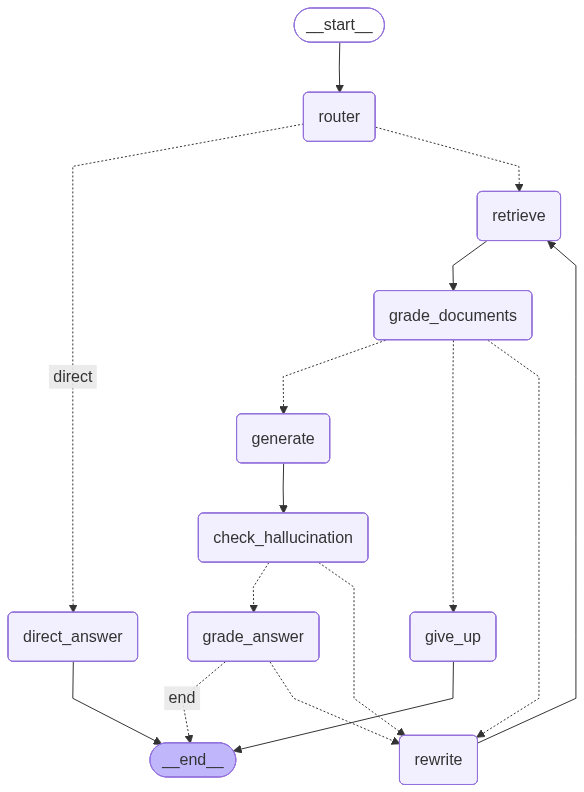

In [ ]:
from IPython.display import Image, display

def route_question(state):
  return "retrieve" if state["route"] == "retrieve" else "direct"

def route_after_grading(state):
  if len(state["documents"]) == 0:
    if state.get("retry_count", 0) >= 2:
      return "give_up"
    return "rewrite"
  return "generate"

def route_after_hallucination(state):
  if "yes" in state.get("hallucination_check", "no"):
    return "grade_answer"
  if state.get("retry_count", 0) >= 2:
    return "grade_answer"
  return "rewrite"

def route_after_answer_grade(state):
  if "yes" in state.get("answer_grade", "no"):
    return "end"
  if state.get("retry_count", 0) >= 2:
    return "end"
  return "rewrite"

def give_up(state):
  print(" [Fallback] Could not find relevant information")
  return {"generation": "I could not find relevant information in the paper to answer this question."}

#Build graph
workflow = StateGraph(GraphState)

workflow.add_node("router", router)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("rewrite", rewrite_query)
workflow.add_node("generate", generate)
workflow.add_node("check_hallucination", check_hallucination)
workflow.add_node("grade_answer", grade_answer)
workflow.add_node("direct_answer", direct_answer)
workflow.add_node("give_up", give_up)

workflow.set_entry_point("router")

workflow.add_conditional_edges("router", route_question, {
    "retrieve": "retrieve",
    "direct": "direct_answer",
})

workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges("grade_documents", route_after_grading, {
    "generate": "generate",
    "rewrite": "rewrite",
    "give_up": "give_up",
})

workflow.add_edge("rewrite", "retrieve")
workflow.add_edge("generate", "check_hallucination")

workflow.add_conditional_edges("check_hallucination", route_after_hallucination, {
    "grade_answer": "grade_answer",
    "rewrite": "rewrite",
})

workflow.add_conditional_edges("grade_answer", route_after_answer_grade, {
    "end": END,
    "rewrite": "rewrite",
})

workflow.add_edge("direct_answer", END)
workflow.add_edge("give_up", END)

app = workflow.compile()

print("Graph built")

display(Image(app.get_graph().draw_mermaid_png()))

## 7. Testing and evaluation

Testing the pipeline with questions of varying difficulty:
- **Simple factual** - answer is in a single section
- **Cross section** - answer requires information from multiple section
- **Interpretive** - requires reasoning beyond what is explicitly stated
- **Out of scope** unrelated to the paper, should route to direct answer

In [ ]:
test_questions = [
    # Simple factual
    ("What is the dimensionality of the model (d_model)?", "simple"),
    ("How many attention heads are used in the model?", "simple"),
    ("What optimizer was used for training?", "simple"),

    # Cross section
    ("How does positional encoding relate to the attention mechanism?", "cross-section"),
    ("What regularization techniques were used and how did they affect results?", "cross-section"),

    # Interpretive
    ("Why did the authors choose self-attention over recurrent layers?", "interpretive"),
    ("What are the trade-offs between single-head and multi-head attention?", "interpretive"),

    # Out of scope
    ("What is the capital of France?", "out of scope"),
    ("How do convolutional neural networks work?", "out of scope"),
]

results = []

for question, category in test_questions:
    print(f"\n{'='*60}")
    print(f"[{category.upper()}] {question}")
    print('='*60)

    output = app.invoke({
        "question": question,
        "documents": [],
        "generation": "",
        "retry_count": 0,
        "route": "",
    })

    results.append({
        "category": category,
        "question": question,
        "answer": output["generation"],
        "route": output.get("route", ""),
    })

    print(f"\nANSWER: {output['generation']}")


[SIMPLE] What is the dimensionality of the model (d_model)?
 [Router] LLM said 'no', keyword match: True -> retrieve
 [Retriever] Found 5 chunks
	1. [6.2] Model Variations
	2. [3.5] Positional Encoding
	3. [3.1] Encoder and Decoder Stacks
	4. [5] Training
	5. [3.3] Position-wise Feed-Forward Networks
 [Grader] Chunk 1: relevant
 [Grader] Chunk 2: relevant
 [Grader] Chunk 3: relevant
 [Grader] Chunk 4: not relevant
 [Grader] Chunk 5: relevant
 [Grader] 4/5 relevant
 [Generator] Generated 3 chars: '512'
 [Hallucination check] Grounded: yes (attempt 1)
 [Answer grader] Useful: yes (Raw: 'yes')

ANSWER: 512

[SIMPLE] How many attention heads are used in the model?
 [Router] LLM said 'no', keyword match: True -> retrieve
 [Retriever] Found 5 chunks
	1. [3.2.2] Multi-Head Attention
	2. [3.2.2] Multi-Head Attention
	3. [3.2] Attention
	4. [Vis] Attention Visualizations
	5. [4] Why Self-Attention
 [Grader] Chunk 1: relevant
 [Grader] Chunk 2: relevant
 [Grader] Chunk 3: relevant
 [Grader] Chu

In [ ]:
print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)

for r in results:
    print(f"\n[{r['category'].upper()}] {r['question']}")
    print(f"  Route: {r['route']}")
    print(f"  Answer: {r['answer'][:150]}")


EVALUATION SUMMARY

[SIMPLE] What is the dimensionality of the model (d_model)?
  Route: retrieve
  Answer: 512

[SIMPLE] How many attention heads are used in the model?
  Route: retrieve
  Answer: h = 8 parallel attention layers, or heads

[SIMPLE] What optimizer was used for training?
  Route: retrieve
  Answer: Adam optimizer

[CROSS-SECTION] How does positional encoding relate to the attention mechanism?
  Route: retrieve
  Answer: This allows every position in the decoder to attend over all positions in the input sequence. This mimics the typical encoder-decoder attention mechan

[CROSS-SECTION] What regularization techniques were used and how did they affect results?
  Route: direct
  Answer: The regularization techniques used were: a) a recursive regularization (regularization) b) a recursive regularization (regularization) c) a recursive 

[INTERPRETIVE] Why did the authors choose self-attention over recurrent layers?
  Route: retrieve
  Answer: Self-attention, sometimes calle

## 8. Bottlenecks, limitations and future improvements

### Current limitations

**1. Model capacity (primary bottleneck)**
The flan-t5-large (780M parameters) produces short, extractive answers rather than
fluent explanations. It tends to copy phrases from the context instead of synthesizing
information. With GPU access and a larger model (Mistral-7B-Instruct, Llama-3-8B),
answer quality would improve significantly. The pipeline is model-agnostic — swapping
requires only changing the model name.

**2. Router reliability**
The LLM-based router (flan-t5) consistently misclassifies questions, requiring a keyword
fallback. The keyword list is incomplete — e.g. "regularization" is missing, causing
relevant questions to route to direct answer instead of retrieval. A stronger model would
make the keyword fallback unnecessary. Alternatively, the keyword list could be expanded,
but this does not scale to arbitrary knowledge bases.

**3. Document grader sensitivity**
With flan-t5-base, grading was unreliable — relevant chunks were rejected and the pipeline
fell back to "no information found". Switching to flan-t5-large improved grading, but it
remains inconsistent. A stronger model or a fine-tuned classifier would make this node
production-ready.

**4. Query rewriter ineffectiveness**
The rewriter rarely produces meaningful reformulations — it often returns the original
question unchanged. This limits the corrective RAG loop's ability to recover from poor
initial retrieval results.

**5. Single-document knowledge base**
The current prototype uses a single 15-page paper. While the architecture scales to
hundreds of documents without modification (ChromaDB handles this natively), the
retriever has not been tested at scale.

### How to measure performance

- **Retrieval quality:** Precision@k and Recall@k against manually labeled relevant chunks
- **Answer quality:** Human evaluation or LLM-as-judge scoring on correctness, completeness,
  and groundedness
- **Pipeline efficiency:** Average number of node traversals per question (fewer = better routing)
- **Latency:** End-to-end response time per question

### Future improvements

- **Stronger generation model** — Mistral-7B or Llama-3-8B with 4-bit quantization on GPU
- **Hybrid retrieval** — combining vector search with BM25 keyword search for better recall
- **Multi-query retrieval** — decomposing complex questions into sub-queries to cover
  multiple sections
- **Streaming output** — using LangGraph's streaming API to show intermediate node decisions
  in real time
- **Evaluation framework** — automated test suite with expected answers for regression testing